# TP5 — Introduction à ClickHouse

**ClickHouse** est une base de données **orientée colonnes** conçue pour l'analytique (**OLAP**).

| | MySQL (row-oriented) | ClickHouse (column-oriented) |
|--|--|--|
| Cas d'usage | Transactions (OLTP) | Analytique (OLAP) |
| Agrégations | Lent sur gros volumes | Très rapide |
| UPDATE/DELETE | Natif | Limité (mutations) |

**Tables disponibles** dans `tp_clickhouse` :
- `web_logs` — Logs serveur web
- `iot_metrics` — Capteurs IoT
- `ecommerce_events` — Événements e-commerce

## 1. Initialisation

In [1]:
!pip install clickhouse-connect pandas seaborn matplotlib -q

In [2]:
import clickhouse_connect
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

client = clickhouse_connect.get_client(host='clickhouse', port=8123,
                                       username='default', password='clickhouse',database='tp_clickhouse')

def query(sql):
    """Exécute une requête SQL et retourne un DataFrame."""
    r = client.query(sql)
    return pd.DataFrame(r.result_rows, columns=r.column_names)

print('ClickHouse', client.command('SELECT version()'))

ClickHouse 24.3.18.7


---
## 2. Exploration de la base

In [3]:
query('SHOW TABLES FROM tp_clickhouse')

,name
0,ecommerce_events
1,iot_metrics
2,web_logs


In [4]:
query('SELECT * FROM web_logs LIMIT 8')

,timestamp,user_id,session_id,url,method,status_code,response_time_ms,bytes_sent,country,browser,os,is_mobile
0,2025-01-15 08:12:33,1001,sess_a1,/index.html,GET,200,45,3200,France,Chrome,Windows,0
1,2025-01-15 08:12:45,1001,sess_a1,/products,GET,200,120,15400,France,Chrome,Windows,0
2,2025-01-15 08:13:10,1001,sess_a1,/products/42,GET,200,88,8900,France,Chrome,Windows,0
3,2025-01-15 08:14:02,1001,sess_a1,/cart,POST,200,210,1200,France,Chrome,Windows,0
4,2025-01-15 08:15:00,1002,sess_b1,/index.html,GET,200,38,3200,Allemagne,Firefox,Linux,0
5,2025-01-15 08:15:30,1002,sess_b1,/search?q=laptop,GET,200,340,22000,Allemagne,Firefox,Linux,0
6,2025-01-15 08:16:00,1003,sess_c1,/index.html,GET,200,52,3200,Espagne,Safari,macOS,0
7,2025-01-15 08:16:20,1003,sess_c1,/products,GET,200,130,15400,Espagne,Safari,macOS,0


In [5]:
for t in ['web_logs', 'iot_metrics', 'ecommerce_events']:
    print(f"{t}: {client.command(f'SELECT count() FROM {t}')} lignes")

web_logs: 100 lignes
iot_metrics: 61 lignes
ecommerce_events: 82 lignes


### Exercice 1
Affichez la structure (`DESCRIBE`) et les 5 premières lignes de `ecommerce_events`.

In [ ]:
# À compléter



,event_time,event_type,product_id,category,brand,price,user_id,user_session
0,2025-01-15 13:00:00,view,501,Livres,Hachette,15.99,1009,sess_i1
1,2025-01-15 13:01:00,view,502,Livres,Gallimard,22.50,1009,sess_i1
2,2025-01-15 09:00:00,view,301,Maison,Dyson,449.99,1003,sess_c1
3,2025-01-15 09:01:00,view,302,Maison,Philips,129.99,1003,sess_c1
4,2025-01-15 12:00:00,view,301,Maison,Dyson,449.99,1008,sess_h1


<details>
<summary>Voir la correction (Exercice 1)</summary>

```python
query('DESCRIBE ecommerce_events')
query('SELECT * FROM ecommerce_events LIMIT 5')
```

</details>

---
## 3. Le moteur MergeTree

MergeTree est le moteur principal de ClickHouse :
- **`ORDER BY`** — tri physique sur disque, accélère les filtres
- **`PARTITION BY`** — découpe par date
- **`TTL`** — suppression automatique des données expirées

In [10]:
print(client.command('SHOW CREATE TABLE ecommerce_events'))

CREATE TABLE tp_clickhouse.ecommerce_events\n(\n    `event_time` DateTime,\n    `event_type` Enum8(\'view\' = 1, \'cart\' = 2, \'purchase\' = 3, \'refund\' = 4),\n    `product_id` UInt32,\n    `category` LowCardinality(String),\n    `brand` LowCardinality(String),\n    `price` Decimal(10, 2),\n    `user_id` UInt32,\n    `user_session` String\n)\nENGINE = MergeTree\nPARTITION BY toYYYYMM(event_time)\nORDER BY (event_type, category, event_time)\nSETTINGS index_granularity = 8192


In [11]:
query("""
SELECT table, partition, rows, formatReadableSize(bytes_on_disk) AS size
FROM system.parts
WHERE database = 'tp_clickhouse' AND active
ORDER BY table, partition
""")

,table,partition,rows,size
0,ecommerce_events,202501,38,1.59 KiB
1,ecommerce_events,202502,20,1.24 KiB
2,ecommerce_events,202503,24,1.33 KiB
3,iot_metrics,202501,35,1.45 KiB
4,iot_metrics,202502,16,1.20 KiB
5,iot_metrics,202503,10,1.11 KiB
6,web_logs,202501,50,2.61 KiB
7,web_logs,202502,28,2.10 KiB
8,web_logs,202503,22,1.99 KiB


---
## 4. Requêtes analytiques — Web logs

ClickHouse utilise un SQL standard enrichi de fonctions analytiques.

### Temps de réponse moyen par pays

In [12]:
query("""
SELECT country, count() AS nb,
       round(avg(response_time_ms), 1) AS avg_ms,
       max(response_time_ms) AS max_ms
FROM tp_clickhouse.web_logs
GROUP BY country
ORDER BY nb DESC
""")

,country,nb,avg_ms,max_ms
0,France,42,1160.5,30000
1,Allemagne,10,144.1,340
2,Espagne,9,256.3,1500
3,Pays-Bas,8,165.0,420
4,Italie,8,153.0,410
5,Belgique,7,145.9,450
6,Royaume-Uni,5,240.0,850
7,Suisse,5,69.0,138
8,Portugal,3,76.3,150
9,Russie,2,11.0,12


### Requêtes par heure — fonctions temporelles

Fonctions utiles : `toHour()`, `toStartOfDay()`,`toMonth()` `toYYYYMM()`

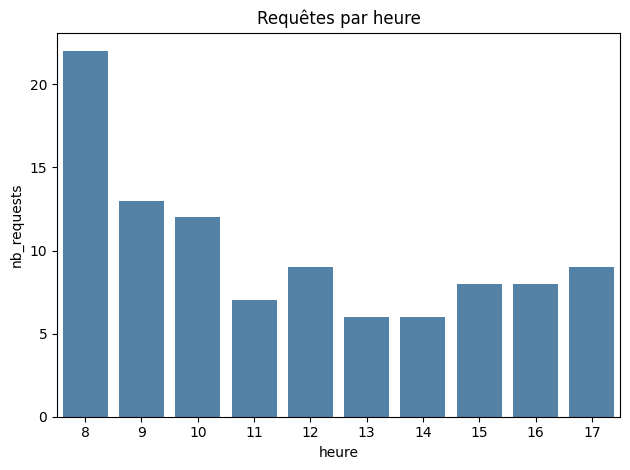

In [31]:
df_h = query("""
SELECT toHour(timestamp) AS heure, count() AS nb_requests
FROM tp_clickhouse.web_logs
GROUP BY heure ORDER BY heure
""")

sns.barplot(data=df_h, x='heure', y='nb_requests', color='steelblue')
plt.title('Requêtes par heure')
plt.tight_layout()
plt.show()
     


### `countIf` / `sumIf` — agrégations conditionnelles

In [36]:
query("""
SELECT toYYYYMM(timestamp) AS mois,
       count() AS total,
       countIf(status_code >= 400) AS erreurs,
        sumIf(bytes_sent, status_code >= 400) AS bytes_erreur
FROM tp_clickhouse.web_logs
GROUP BY mois ORDER BY mois
""")

,mois,total,erreurs,bytes_erreur
0,202501,50,6,1230
1,202502,28,1,80
2,202503,22,1,250


### Exercice 2
Calculez le nombre de requêtes et le volume total (`sum(bytes_sent)`) par **navigateur** (`browser`). Triez par volume décroissant.

In [ ]:
# À compléter


,browser,total_requests,volume_total
0,Chrome,54,632580
1,Firefox,21,156500
2,Safari,14,101100
3,Edge,11,91790


<details>
<summary>Voir la correction (Exercice 2)</summary>

```python
query("""
SELECT browser,
       count() AS nb_requetes,
       sum(bytes_sent) AS volume_total
FROM web_logs
GROUP BY browser
ORDER BY volume_total DESC
""")
```

</details>

### Exercice 3
Comparez les performances **mobile vs desktop** (`is_mobile`) : nombre de requêtes, temps de réponse moyen, nombre d'erreur.

In [47]:
# À compléter


<details>
<summary>Voir la correction (Exercice 3)</summary>

```python
query("""
SELECT if(is_mobile = 1, 'mobile', 'desktop') AS plateforme,
       count() AS nb_requetes,
       round(avg(response_time_ms), 1) AS avg_ms,
       countIf(status_code >= 400) AS erreurs,
FROM web_logs
GROUP BY is_mobile
ORDER BY nb_requetes DESC
""")
```

</details>

---
## 5. Séries temporelles — IoT

ClickHouse excelle sur les séries temporelles grâce à ses fonctions de date et ses agrégations optimisées.

,timestamp,device_id,device_type,location,temperature,humidity,battery_pct,signal_strength
0,2025-01-15 00:00:00,sensor_003,humidity,Marseille,20.100000,55.000000,92,-38
1,2025-01-15 00:05:00,sensor_003,humidity,Marseille,20.000000,55.299999,92,-39
2,2025-01-15 00:10:00,sensor_003,humidity,Marseille,19.799999,55.799999,91,-38
3,2025-01-15 00:15:00,sensor_003,humidity,Marseille,19.600000,56.200001,91,-40
4,2025-01-15 00:20:00,sensor_003,humidity,Marseille,19.500000,56.500000,91,-39


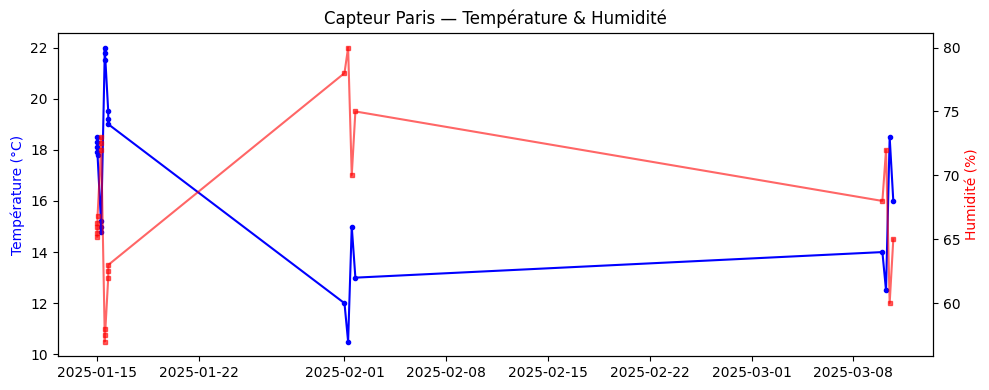

In [52]:
df_paris = query("""
SELECT timestamp, temperature, humidity
FROM iot_metrics
WHERE location = 'Paris'
ORDER BY timestamp
""")

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(df_paris['timestamp'], df_paris['temperature'], 'b-o', markersize=3, label='Temp °C')
ax1.set_ylabel('Température (°C)', color='blue')
ax2 = ax1.twinx()
ax2.plot(df_paris['timestamp'], df_paris['humidity'], 'r-s', markersize=3, alpha=0.6, label='Humidité %')
ax2.set_ylabel('Humidité (%)', color='red')
plt.title('Capteur Paris — Température & Humidité')
plt.tight_layout()
plt.show()

In [58]:
query("""
SELECT toStartOfDay(timestamp) AS jour, device_id,
       round(avg(temperature), 2) AS avg_temp
FROM iot_metrics
WHERE device_type = 'temperature'
GROUP BY jour, device_id
ORDER BY device_id, jour
""")

,jour,device_id,avg_temp
0,2025-01-15,sensor_001,18.47
1,2025-02-01,sensor_001,12.62
2,2025-03-10,sensor_001,15.25
3,2025-01-15,sensor_002,15.98
4,2025-02-01,sensor_002,10.75
5,2025-03-10,sensor_002,14.50
6,2025-02-01,sensor_005,11.88
7,2025-03-10,sensor_005,15.25


### Exercice 4
Calculez la température moyenne par **mois** et par **ville** (`location`). Utilisez `toStartOfMonth()`.

,location,mois,avg_temp
0,Bordeaux,2025-02-01,11.88
1,Bordeaux,2025-03-01,15.25
2,Lyon,2025-01-01,15.98
3,Lyon,2025-02-01,10.75
4,Lyon,2025-03-01,14.50
5,Paris,2025-01-01,18.47
6,Paris,2025-02-01,12.62
7,Paris,2025-03-01,15.25


<details>
<summary>Voir la correction (Exercice 4)</summary>

```python
query("""
SELECT toStartOfMonth(timestamp) AS mois,
       location,
       round(avg(temperature), 2) AS temperature_moyenne
FROM iot_metrics
WHERE device_type = 'temperature'
GROUP BY mois, location
ORDER BY mois, location
""")
```

</details>

---
## 6. Analyse e-commerce — Parcours d'achat

Le parcours d'achat classique : `view -> cart -> purchase`. On utilise `countIf()` et `sumIf()` pour l'analyser.

/tmp/ipykernel_151/2758511495.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ev, x='event_type', y='nb',


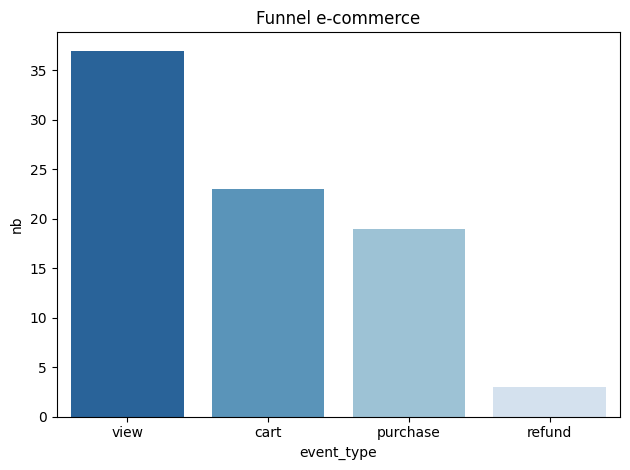

In [ ]:
df_ev = query("""
SELECT event_type, count() AS nb
FROM ecommerce_events
GROUP BY event_type ORDER BY nb DESC
""")

sns.barplot(data=df_ev, x='event_type', y='nb',
            order=['view','cart','purchase','refund'], palette='Blues_r')
plt.title("Parcours d'achat e-commerce")
plt.tight_layout()
plt.show()

In [ ]:
query("""
SELECT category,
       countIf(event_type = 'view') AS vues,
       countIf(event_type = 'purchase') AS achats,
       round(sumIf(price, event_type = 'purchase'), 2) AS CA,
       round(countIf(event_type = 'purchase') * 100.0 / countIf(event_type = 'view'), 1) AS conversion_pct
FROM tp_clickhouse.ecommerce_events
GROUP BY category
ORDER BY CA DESC
""")

### Exercice 5
Calculez le chiffre d'affaires par **marque** (`brand`), uniquement pour les achats. Triez par CA décroissant.

In [ ]:
# À compléter

<details>
<summary>Voir la correction (Exercice 5)</summary>

```python
query("""
SELECT brand,
       round(sum(price), 2) AS chiffre_affaires
FROM ecommerce_events
WHERE event_type = 'purchase'
GROUP BY brand
ORDER BY chiffre_affaires DESC
""")
```

</details>

### Exercice 6
Calculez le **CA net** par mois (`toStartOfMonth`) : achats − remboursements. Utilisez `sumIf()`.

In [ ]:
# À compléter

<details>
<summary>Voir la correction (Exercice 6)</summary>

```python
query("""
SELECT toStartOfMonth(event_time) AS mois,
       round(sumIf(price, event_type = 'purchase') - sumIf(price, event_type = 'refund'), 2) AS ca_net
FROM ecommerce_events
GROUP BY mois
ORDER BY mois
""")
```

</details>

---
## 7. Fonctions avancées

- **`quantile(0.9)(col)`** — percentiles
- **`groupArray(col)`** — agrège en tableau
- **`multiIf(cond1, val1, …, default)`** — conditions multiples

In [ ]:
query("""
SELECT quantile(0.5)(response_time_ms) AS p50,
       quantile(0.9)(response_time_ms) AS p90,
       quantile(0.99)(response_time_ms) AS p99
FROM tp_clickhouse.web_logs
""")

In [ ]:
query("""
SELECT country,
       groupArray(DISTINCT browser) AS navigateurs
FROM tp_clickhouse.web_logs
GROUP BY country
ORDER BY length(groupArray(DISTINCT browser)) DESC
""")

### Exercice 7
Classifiez les requêtes web en catégories de performance avec `multiIf()` :
- < 100 ms → `rapide`
- < 500 ms → `normal`
- < 2000 ms → `lent`
- sinon → `très lent`

Affichez le nombre de requêtes et le temps moyen par catégorie.

In [ ]:
# À compléter

<details>
<summary>Voir la correction (Exercice 7)</summary>

```python
query("""
SELECT multiIf(response_time_ms < 100, 'rapide',
               response_time_ms < 500, 'normal',
               response_time_ms < 2000, 'lent',
               'tres lent') AS categorie_performance,
       count() AS nb_requetes,
       round(avg(response_time_ms), 1) AS temps_moyen_ms
FROM web_logs
GROUP BY categorie_performance
ORDER BY multiIf(categorie_performance = 'rapide', 1,
                 categorie_performance = 'normal', 2,
                 categorie_performance = 'lent', 3,
                 4)
""")
```

</details>

---
## Résumé

| Concept | Ce qu'on a vu |
|---------|---------------|
| Architecture | Stockage colonnes, MergeTree, partitions |
| Types | LowCardinality, Enum, UInt, DateTime |
| Analytique | GROUP BY, countIf, sumIf, quantile |
| Séries temporelles | toHour, toStartOfDay, toStartOfMonth |
| Fonctions avancées | groupArray, multiIf |

[Documentation ClickHouse](https://clickhouse.com/docs) · [Playground](https://play.clickhouse.com/)